In [1]:
#importing library file
import pandas as pd

In [2]:
#Providing input sheet to dataset
dataset=pd.read_csv("50_Startups.csv")

In [3]:
#viewing data saved in dataset variable
dataset

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
#here we are doing one hot encoding as state is nominal data.get_dummies function work is to .saving the dataset with the updated values for nomail data in 0s and 1s format
#as we use one hot encoding we have column expansion. so there will be increase in columns.the name for column will be like initial column name with the nomial valu
#according to machine learning we have dummies in one hot encoding.so we have to delete one column to reduce memory and to avoid dummies
#so when we give drop_first=true then first column will be dropped which means it is deleted. by default it is false.
dataset=pd.get_dummies(dataset,dtype = int,drop_first=True)

In [5]:
dataset

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,0,0
7,130298.13,145530.06,323876.68,155752.60,1,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,0,0


In [6]:
# to get column names saved under dataset variable
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [8]:
#input variable assigning values
Independent=dataset[['R&D Spend', 'Administration', 'Marketing Spend', 
       'State_Florida', 'State_New York']]

In [9]:
#checking saved values
Independent

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,0,0
2,153441.51,101145.55,407934.54,1,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,1,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,0,0
7,130298.13,145530.06,323876.68,1,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,0,0


In [10]:
#assinging ouput column
Dependent=dataset[['Profit']]

In [11]:
#checking data saved in the variable
Dependent

,Profit
0,192261.83
1,191792.06
2,191050.39
3,182901.99
4,166187.94
5,156991.12
6,156122.51
7,155752.60
8,152211.77
9,149759.96


In [12]:
#step 2: to seprate test set and trail set for this we need new library file(sklearn).here importing only needed function
#so within library file we are using only needed class and function- to reduce memory. if we import all library file from sklearn the memory will be huge

from sklearn.model_selection import train_test_split

In [13]:
#we are seeing what is there in this function. here we are passing paramter as this is parameterised function
#choosing test size as 30% so that trail data will be more and test data will be less.
train_test_split(Independent,Dependent,test_size=0.30,random_state=0)

[    R&D Spend  Administration  Marketing Spend  State_Florida  State_New York
 7   130298.13       145530.06        323876.68              1               0
 14  119943.24       156547.42        256512.92              1               0
 45    1000.23       124153.04          1903.93              0               1
 48     542.05        51743.15             0.00              0               1
 29   65605.48       153032.06        107138.38              0               1
 15  114523.61       122616.84        261776.23              0               1
 30   61994.48       115641.28         91131.24              1               0
 32   63408.86       129219.61         46085.25              0               0
 16   78013.11       121597.55        264346.06              0               0
 42   23640.93        96189.63        148001.11              0               0
 20   76253.86       113867.30        298664.47              0               0
 43   15505.73       127382.30         35534.17     

In [14]:
#based on the output we received here we can see 4 varibles is used here.so we are using varibale to assign this output
# so we are going to use 4 varibales x_train,x_test,y_train,y_test. ouputare seprated by commans. so here we have 4 set of data saved
X_train,X_test,Y_train,Y_test=train_test_split(Independent,Dependent,test_size=0.30,random_state=0)

In [15]:
#checking one variable to check what data is saved
X_train

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
7,130298.13,145530.06,323876.68,1,0
14,119943.24,156547.42,256512.92,1,0
45,1000.23,124153.04,1903.93,0,1
48,542.05,51743.15,0.00,0,1
29,65605.48,153032.06,107138.38,0,1
15,114523.61,122616.84,261776.23,0,1
30,61994.48,115641.28,91131.24,1,0
32,63408.86,129219.61,46085.25,0,0
16,78013.11,121597.55,264346.06,0,0
42,23640.93,96189.63,148001.11,0,0


In [16]:
#now we are going to create decision tree model.
#creating the variable as regressor best practise is to use the varibale like this and assiging a class to this variable
 #using default value in parameter
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor()
regressor=regressor.fit(X_train,Y_train)

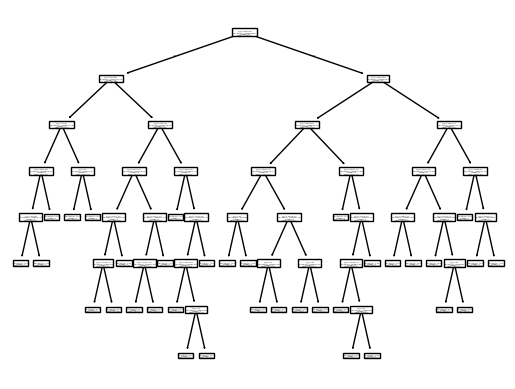

In [17]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [18]:
#evaluation metrics. if values is nearly 1 then model created is fine if nearly 0 then model is not good
#so we are going to find the predicted value for the test data. x test is the input value and y test is the output value
y_pred=regressor.predict(X_test)

In [19]:
#to calculate the r_score we need y test value and y predicted value.so with that score is calculated
from sklearn.metrics import r2_score
r_score=r2_score(Y_test,y_pred)

In [20]:
# as value is nearly 1 this is good model. before saving we should check the performance of the model
r_score

0.9135189988165733

In [21]:
#trying to give parameters as squared_error and random
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='squared_error',splitter='random')
regressor=regressor.fit(X_train,Y_train)

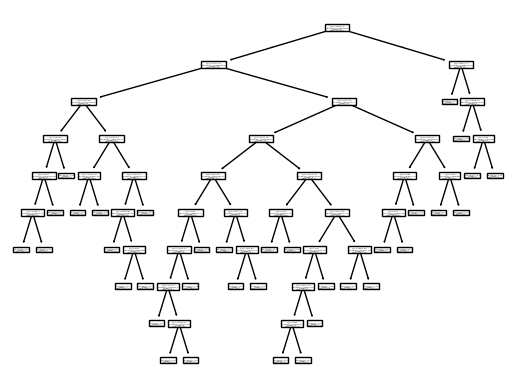

In [22]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [23]:
y_pred=regressor.predict(X_test)

from sklearn.metrics import r2_score
r_score=r2_score(Y_test,y_pred)
r_score

0.368556509899592

In [24]:
#trying to give parameters as friedman_mse and random
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='friedman_mse',splitter='random')
regressor=regressor.fit(X_train,Y_train)

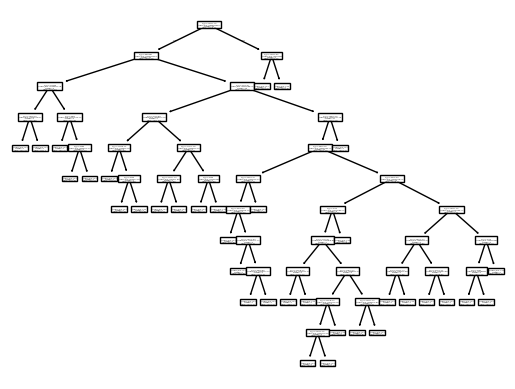

In [25]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [26]:
y_pred=regressor.predict(X_test)

from sklearn.metrics import r2_score
r_score=r2_score(Y_test,y_pred)
r_score

0.7224241920168086

In [27]:
#trying to give parameters as friedman_mse and best
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='friedman_mse',splitter='best')
regressor=regressor.fit(X_train,Y_train)

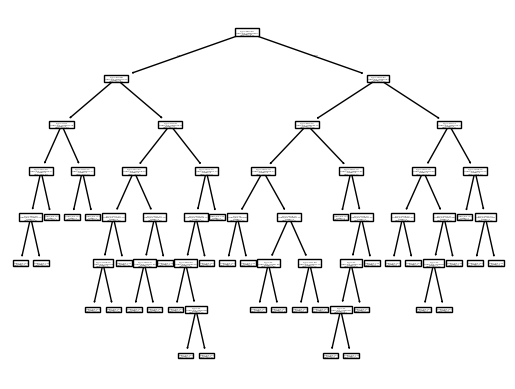

In [28]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [29]:
y_pred=regressor.predict(X_test)

from sklearn.metrics import r2_score
r_score=r2_score(Y_test,y_pred)
r_score

0.921072540271293

In [30]:
#trying to give parameters as absolute_error and best
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='absolute_error',splitter='best')
regressor=regressor.fit(X_train,Y_train)

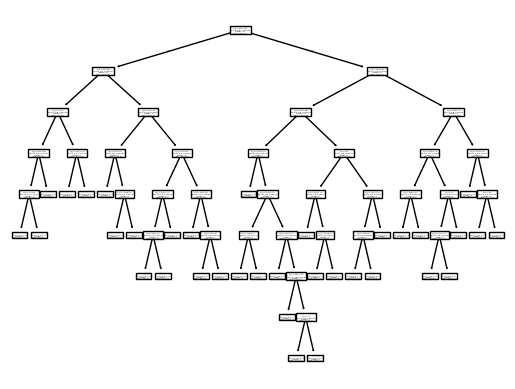

In [31]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [32]:
y_pred=regressor.predict(X_test)

from sklearn.metrics import r2_score
r_score=r2_score(Y_test,y_pred)
r_score

0.9521650663795127

In [35]:
#trying to give parameters as absolute_error and random
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='absolute_error',splitter='random')
regressor=regressor.fit(X_train,Y_train)

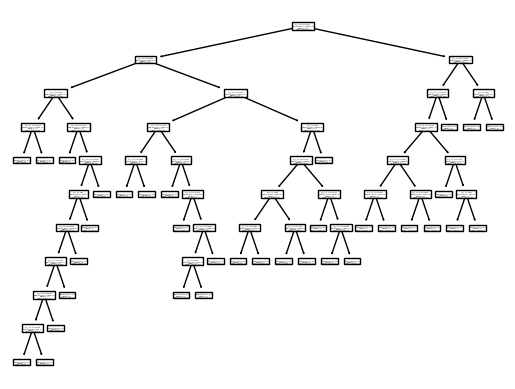

In [36]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [37]:
y_pred=regressor.predict(X_test)

from sklearn.metrics import r2_score
r_score=r2_score(Y_test,y_pred)
r_score

0.5940600494789416

In [39]:
#trying to give parameters as poisson and random
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='poisson',splitter='random')
regressor=regressor.fit(X_train,Y_train)

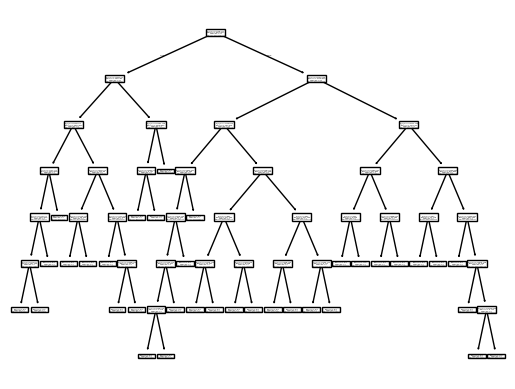

In [40]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [41]:
y_pred=regressor.predict(X_test)

from sklearn.metrics import r2_score
r_score=r2_score(Y_test,y_pred)
r_score

0.9206959077436739

In [42]:
#trying to give parameters as poisson and best
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='poisson',splitter='best')
regressor=regressor.fit(X_train,Y_train)

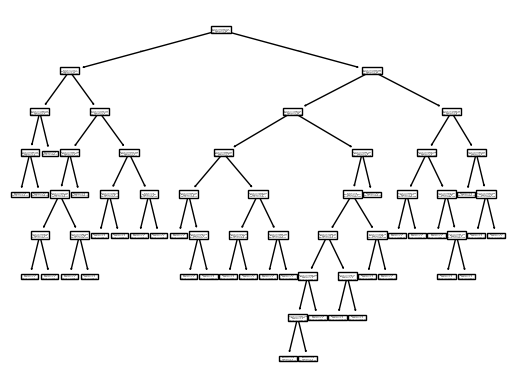

In [43]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [44]:
y_pred=regressor.predict(X_test)

from sklearn.metrics import r2_score
r_score=r2_score(Y_test,y_pred)
r_score

0.9079268866915345